# Lab 2 (SOLUTION) — Design and Randomise the Injaz Uploader Experiment
# المختبر 2 — تصميم وعشوَنة تجربة رافع المستندات في إنجاز

**Module 2 · الوحدة 2 — Experiment Design and Randomisation / تصميم التجارب والعشوائية**
SDA-DSC-213 · Experimentation, A/B Testing and Causal Inference · SDAIA Academy

---

### Where Lab 1 left you

Lab 1 proved that a coin flip removes the selection-bias term. This lab does the coin
flip **for real**, on 182,113 eligible Injaz users, and then proves the flip actually
worked. A powerful analysis cannot rescue a broken design — this is the hour where
experiments are won or lost.

### What you will build

| # | Step | Minutes |
|---|---|---|
| 1 | The **design doc**: hypothesis, unit, OEC, guardrails, trigger, unit of analysis | 10 |
| 2 | `assign_variant` — deterministic **hash-based** assignment, then the library version | 8 |
| 3 | The **SRM** check: pass on clean data, then deliberately break it | 7 |
| 4 | The **balance table** over age, literacy, prior completions and region | 10 |
| 5 | The **interference audit** — two SUTVA risks and the design change each demands | 8 |
| 6 | The **frozen analysis plan** handed to Lab 4 | 7 |

### The vocabulary this lab installs (bilingual, once)

- **randomisation unit (وحدة العشوَنة)** — what gets independently coin-flipped.
- **OEC / Overall Evaluation Criterion (معيار التقييم الشامل)** — the single metric that decides the experiment.
- **guardrail metric (مقياس الحماية)** — a metric that must not get worse, whatever the OEC does.
- **trigger / exposure (التفعيل)** — the moment a unit actually experiences the difference.
- **SUTVA (فرضية ثبات قيمة معالجة الوحدة)** — no interference between units, one version of the treatment.
- **SRM / Sample Ratio Mismatch (عدم تطابق نسبة العينة)** — observed arm sizes differ from the planned split.
- **covariate balance (توازن المتغيرات المصاحبة)** — the arms look alike on everything measured before assignment.

> All code, variables and comments stay in **English**.


---
## Step 0 — The eligible pool

`injaz_users_pool.csv` is the population **before** the experiment: 200,000 users,
no outcomes. That absence is deliberate. Everything in this notebook must be decidable
without seeing a single outcome — that is what makes the design honest.


In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Make `causal_utils` importable from anywhere under course_assets/
ROOT = Path.cwd()
while not (ROOT / "causal_utils").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
DATA = ROOT / "data"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from causal_utils import use_sdaia_style
use_sdaia_style()

RANDOM_SEED = 213          # fixed for every lab: reproducibility is graded
rng = np.random.default_rng(RANDOM_SEED)
print("Environment ready ·", ROOT)

Environment ready · /home/claude/course_assets


In [2]:
def needs(*values, msg="complete the TODO in the cell above, then re-run this cell"):
    """Guard for the start notebook: True (with a friendly note) if a TODO is unfinished."""
    if any(v is None for v in values):
        print(f"[not implemented yet] {msg}")
        return True
    return False

In [3]:
import json
from causal_utils import (hash_assign, srm_check, standardised_mean_difference,
                          balance_table, NAVY, BLUE, ORANGE, TEAL, SLATE, MUTED, PANEL)

with open(DATA / "GROUND_TRUTH.json") as f:
    GROUND_TRUTH = json.load(f)

pool = pd.read_csv(DATA / "injaz_users_pool.csv")
eligible = pool.loc[pool["is_eligible"] == 1].copy().reset_index(drop=True)

print(f"pool rows      : {len(pool):,}")
print(f"eligible rows  : {len(eligible):,}   ({eligible.shape[0] / len(pool):.1%} of the pool)")
print(f"ground truth   : {GROUND_TRUTH['module2_user_pool']}")
print()
print(eligible[["user_id", "region", "age", "device", "prior_sessions",
                "prior_completion_rate", "digital_literacy_score"]].head())
print()
print("NOTE: there is no outcome column in this file, and there must not be. Every")
print("choice below is made blind to results — that is the definition of a design.")

pool rows      : 200,000
eligible rows  : 182,113   (91.1% of the pool)
ground truth   : {'rows': 200000, 'eligible': 182113}

   user_id  region  age   device  prior_sessions  prior_completion_rate  \
0        1    Asir   27  desktop               3                 0.7117   
1        2  Makkah   24  android               5                 0.5575   
2        3  Riyadh   25  android               8                 0.4673   
3        5  Makkah   19  desktop               7                 0.5174   
4        6  Makkah   36  android               4                 0.6353   

   digital_literacy_score  
0                  0.8233  
1                  0.7548  
2                  0.7549  
3                  0.7317  
4                  0.6785  

NOTE: there is no outcome column in this file, and there must not be. Every
choice below is made blind to results — that is the definition of a design.


---
## Step 1 *(10 min)* — The design doc

Fill every field. A field you cannot fill is a decision you have not made, and it will
be made for you later by whoever is looking at the dashboard.

**The rule for the randomisation unit:** *randomise at the coarsest unit interference
demands, and no coarser.* Coarser units contain spillover; they also destroy power.

Two sentences you must be able to defend out loud:

> *Why user and not session?*
> *Why is completion rate the OEC and not clicks on the upload button?*


In [4]:
DESIGN_DOC = {
    "experiment_name": "injaz-guided-uploader-2026q2",
    "decision": ("Ship the guided document uploader to all Injaz users, or keep the "
                 "current plain uploader?"),
    "hypothesis": ("The guided uploader reduces upload errors and abandonment at the "
                   "document step, raising end-to-end service completion by at least "
                   "1 percentage point among users who reach that step."),

    "randomisation_unit": "user (national-ID hash)",
    "randomisation_unit_justification": (
        "Citizens return across sessions to finish one service. Randomising by session "
        "would show the same citizen two different upload flows in one week - a data "
        "problem (sessions within a user are not independent) and a trust problem for a "
        "government service. Interference between users is negligible here: nothing one "
        "user uploads changes another user's flow, so we do not need to coarsen further "
        "to region or household."),

    "unit_of_analysis": "user",
    "oec": "service-completion rate among triggered users",
    "oec_justification": (
        "Completion is sensitive to the change, unambiguously directional, and is the "
        "outcome the ministry is actually funded to deliver. 'Clicks on the upload "
        "button' fails the directional test - a confusing button earns more clicks."),

    "guardrails": [
        "time-to-complete (session_duration_sec) - must not rise materially",
        "support-contact rate - must not rise",
        "upload-error rate (error_flag) - must not rise",
    ],
    "diagnostics": ["step-level drop-off", "trigger rate", "retries per upload"],
    "data_quality_checks": ["sample ratio (SRM)", "covariate balance", "missing-data rate"],

    "trigger_definition": "user reaches the document-upload step at least once",
    "allocation": {"control": 0.5, "treatment": 0.5},
    "salt": "injaz-uploader-2026q2",
    "mde_absolute": 0.02,
    "alpha": 0.05,
    "power": 0.80,
    "practical_threshold": 0.01,
    "stopping_rule": "fixed horizon; no interim stopping for significance",
}

for k, v in DESIGN_DOC.items():
    if isinstance(v, list):
        print(f"{k}:")
        for item in v:
            print(f"    - {item}")
    elif isinstance(v, dict):
        print(f"{k}: {v}")
    else:
        print(f"{k}: {v}")

required = {"randomisation_unit", "oec", "guardrails", "trigger_definition",
            "unit_of_analysis", "hypothesis"}
missing = required - set(DESIGN_DOC)
assert not missing, f"design doc incomplete: {missing}"
assert len(DESIGN_DOC["guardrails"]) >= 3, "at least three guardrails"
print("\\nDesign doc: all six required fields present.")

experiment_name: injaz-guided-uploader-2026q2
decision: Ship the guided document uploader to all Injaz users, or keep the current plain uploader?
hypothesis: The guided uploader reduces upload errors and abandonment at the document step, raising end-to-end service completion by at least 1 percentage point among users who reach that step.
randomisation_unit: user (national-ID hash)
randomisation_unit_justification: Citizens return across sessions to finish one service. Randomising by session would show the same citizen two different upload flows in one week - a data problem (sessions within a user are not independent) and a trust problem for a government service. Interference between users is negligible here: nothing one user uploads changes another user's flow, so we do not need to coarsen further to region or household.
unit_of_analysis: user
oec: service-completion rate among triggered users
oec_justification: Completion is sensitive to the change, unambiguously directional, and is t

> ### Instructor note — Step 1
>
> **Teaching point.** The design doc is the deliverable, not the code. Spend the full ten
> minutes. The two justification fields are where the learning is: make at least one pair
> read their "why user, not session" sentence aloud and let the room attack it.
>
> **Common wrong answer.** Five "primary" metrics, because the PM "wants to learn more".
> Name the statistical cost immediately — five independent tests at α = 0.05 give a 23%
> chance of at least one false positive — and offer the counter-proposal: one OEC, a
> guardrail family with Bonferroni, everything else labelled diagnostic.
>
> **When a participant is stuck.** The trigger definition is the field people skip. Ask:
> "A user logs in, pays a fee, never touches a document. Is that user in your denominator?"
> If they hesitate, they have found the Lab 4 trap early — good.

---
## Step 2 *(8 min)* — Build the assignment yourself, then check it

Assignment must be **deterministic, uniform, and independent across experiments**. The
professional pattern is hashing, not a per-request random draw:

```
hash(salt + ":" + unit_id) -> first 8 hex chars -> integer -> u in [0, 1) -> bucket
```

Three properties fall out for free:

1. **Deterministic** — the same user lands in the same arm on every request, with no
   stored state and no database lookup at serving time.
2. **Reproducible** — the analysis pipeline re-derives the assignment months later.
3. **Independent across experiments** — a different `salt` gives a fresh, uncorrelated
   bucketing, so concurrent experiments do not confound each other. Reusing a salt is
   how two teams silently ruin each other's results.

Build it yourself first. Then compare against `causal_utils.hash_assign` — they must
agree on **100%** of users, or one of you is wrong.


In [5]:
import hashlib

def assign_variant(unit_id, experiment_salt, split=(0.5, 0.5),
                   arms=("control", "treatment")):
    """Map one unit deterministically to an arm.

    Hashing, not np.random: reproducible, stateless, and independent across
    experiments through the salt.
    """
    assert abs(sum(split) - 1.0) < 1e-9, "split must sum to 1"
    digest = hashlib.md5(f"{experiment_salt}:{unit_id}".encode()).hexdigest()
    u = int(digest[:8], 16) / 0xFFFFFFFF          # 8 hex chars -> uniform in [0, 1)
    cumulative = 0.0
    for arm, share in zip(arms, split):
        cumulative += share
        if u < cumulative:
            return arm
    return arms[-1]


SALT = DESIGN_DOC["salt"]

mine = np.array([assign_variant(uid, SALT) for uid in eligible["user_id"].to_numpy()])
library = hash_assign(eligible["user_id"].to_numpy(), SALT,
                      weights=(0.5, 0.5), arm_names=("control", "treatment"))

eligible["variant"] = library

print(f"agreement with causal_utils.hash_assign : {(mine == library).mean():.4%}")
print()
print("Determinism check — re-run the assignment three times and compare:")
repeats = [np.array([assign_variant(uid, SALT) for uid in eligible["user_id"].head(5_000)])
           for _ in range(3)]
print(f"  identical across 3 re-runs : {all((repeats[0] == r).all() for r in repeats)}")
print()
print("Independence across experiments — the SAME users under a different salt:")
other = hash_assign(eligible["user_id"].head(50_000).to_numpy(), "injaz-autofill-2026q4")
same_bucket = (other == library[:50_000]).mean()
print(f"  share landing in the same arm under a new salt : {same_bucket:.3f}   (want ~0.50)")
print()
print(eligible["variant"].value_counts().to_string())

agreement with causal_utils.hash_assign : 100.0000%

Determinism check — re-run the assignment three times and compare:
  identical across 3 re-runs : True

Independence across experiments — the SAME users under a different salt:
  share landing in the same arm under a new salt : 0.499   (want ~0.50)

variant
treatment    91167
control      90946


> ### Instructor note — Step 2
>
> **Teaching point.** The salt demo is the part people have never seen. Under a second
> salt, ~50% of users swap arms — that is what "independent bucketing across concurrent
> experiments" means, and it is why every experiment needs its own salt string.
>
> **Common wrong answer.** `np.random.binomial(1, 0.5, len(users))`. It passes SRM, it
> passes balance, and it is still wrong: re-run the notebook and every user moves. Ask the
> room what the serving layer does when a user returns tomorrow.
>
> **When a participant is stuck.** Agreement below 100% is almost always the divisor
> (`0xFFFFFFFF`, not `1e8`) or `sha256` instead of `md5`. Have them print the first three
> `u` values from both implementations side by side.

### ✅ Checkpoint A — what you should be seeing by now

≈20 minutes in. Design doc complete, 182,113 users assigned, your hash agreeing with the
library on 100% of them, and the arms sitting close to 91,000 each.


In [6]:
def checkpoint_a():
    if eligible["variant"].isna().all():
        print("✗ Step 2 incomplete — assign_variant is still a TODO.")
        return
    counts = eligible["variant"].value_counts()
    print(f"✓ design doc fields set   : {sum(v is not None for v in DESIGN_DOC.values())}/{len(DESIGN_DOC)}")
    print(f"✓ users assigned          : {len(eligible):,}")
    print(f"✓ control / treatment     : {counts.get('control', 0):,} / {counts.get('treatment', 0):,}")
    print(f"✓ treatment share         : {(eligible['variant'] == 'treatment').mean():.4f}   (planned 0.5000)")
    print()
    print("Next: prove the split is not just close, but statistically consistent with 50/50.")

checkpoint_a()

✓ design doc fields set   : 19/19
✓ users assigned          : 182,113
✓ control / treatment     : 90,946 / 91,167
✓ treatment share         : 0.5006   (planned 0.5000)

Next: prove the split is not just close, but statistically consistent with 50/50.


---
## Step 3 *(7 min)* — Sample Ratio Mismatch, and what a real bug looks like

You planned 50/50 and observed 91,167 / 90,946. Is that fine, or is it a bug?

The SRM check is a chi-square test of the observed arm counts against the planned split.
Two things about it that matter more than the arithmetic:

1. **α = 0.001, not 0.05.** With hundreds of thousands of units, harmless deviations trip
   a 5% threshold constantly, and a real SRM is usually catastrophic enough to blow past
   0.001 anyway.
2. **A failed SRM is not something you adjust for.** It means units were lost or
   misassigned *non-randomly*, so the comparison is no longer a randomised one. The
   correct response is to find the bug and rerun. **Never analyse an SRM-failing test.**

Build the check, confirm it passes — then deliberately drop 3% of the treatment arm,
the way a broken redirect or a logging race would, and watch it fail.


In [7]:
from scipy import stats

def srm_check_manual(variant_series, expected_split, alpha=0.001):
    """Chi-square goodness-of-fit on arm counts. Returns a dict you can print."""
    counts = variant_series.value_counts()
    arms = list(counts.index)
    total = int(counts.sum())
    observed = counts.to_numpy(dtype=float)
    expected = np.array([expected_split[a] * total for a in arms], dtype=float)
    chi2 = float(((observed - expected) ** 2 / expected).sum())
    p = float(stats.chi2.sf(chi2, df=len(arms) - 1))
    return {"arms": arms, "observed": observed.astype(int).tolist(),
            "expected": expected.round(0).astype(int).tolist(),
            "chi2": round(chi2, 3), "p_value": p,
            "srm_detected": p < alpha,
            "verdict": "INVALID — investigate plumbing" if p < alpha else "ratios OK"}


expected_split = DESIGN_DOC["allocation"]

print("A. Clean assignment")
srm_clean = srm_check_manual(eligible["variant"], expected_split)
print(f"   {srm_clean}")
print()
print("   causal_utils cross-check:")
print(srm_check(eligible["variant"], expected_split))

# --- inject the bug: silently lose 3% of the treatment arm ----------------
g = np.random.default_rng(RANDOM_SEED)
treatment_rows = eligible.index[eligible["variant"] == "treatment"]
dropped = g.choice(treatment_rows, size=int(0.03 * len(treatment_rows)), replace=False)
broken = eligible.drop(index=dropped)

print("\nB. After a redirect silently drops 3% of the treatment arm")
srm_broken = srm_check_manual(broken["variant"], expected_split)
print(f"   {srm_broken}")
print()
print(srm_check(broken["variant"], expected_split))
print()
print(f"Ground-truth reference: the course's pre-broken file sits at a treatment share of "
      f"{GROUND_TRUTH['module4_uploader_experiment']['srm_broken_allocation']:.4f}.")
print("A 3% loss on one arm is a 1.4% ratio drift — invisible to the eye, fatal to the test.")

A. Clean assignment
   {'arms': ['treatment', 'control'], 'observed': [91167, 90946], 'expected': [91056, 91056], 'chi2': 0.268, 'p_value': 0.6045481041495773, 'srm_detected': False, 'verdict': 'ratios OK'}

   causal_utils cross-check:
Sample Ratio Mismatch check: PASS
  chi2 = 0.27   p = 0.605
  treatment    observed   91,167   expected     91,056   (+0.12%)
  control      observed   90,946   expected     91,056   (-0.12%)



B. After a redirect silently drops 3% of the treatment arm
   {'arms': ['control', 'treatment'], 'observed': [90946, 88432], 'expected': [89689, 89689], 'chi2': 35.234, 'p_value': 2.9238137286893546e-09, 'srm_detected': True, 'verdict': 'INVALID — investigate plumbing'}

Sample Ratio Mismatch check: *** SRM — EXPERIMENT INVALID ***
  chi2 = 35.23   p = 2.92e-09
  control      observed   90,946   expected     89,689   (+1.40%)
  treatment    observed   88,432   expected     89,689   (-1.40%)

Ground-truth reference: the course's pre-broken file sits at a treatment share of 0.4928.
A 3% loss on one arm is a 1.4% ratio drift — invisible to the eye, fatal to the test.


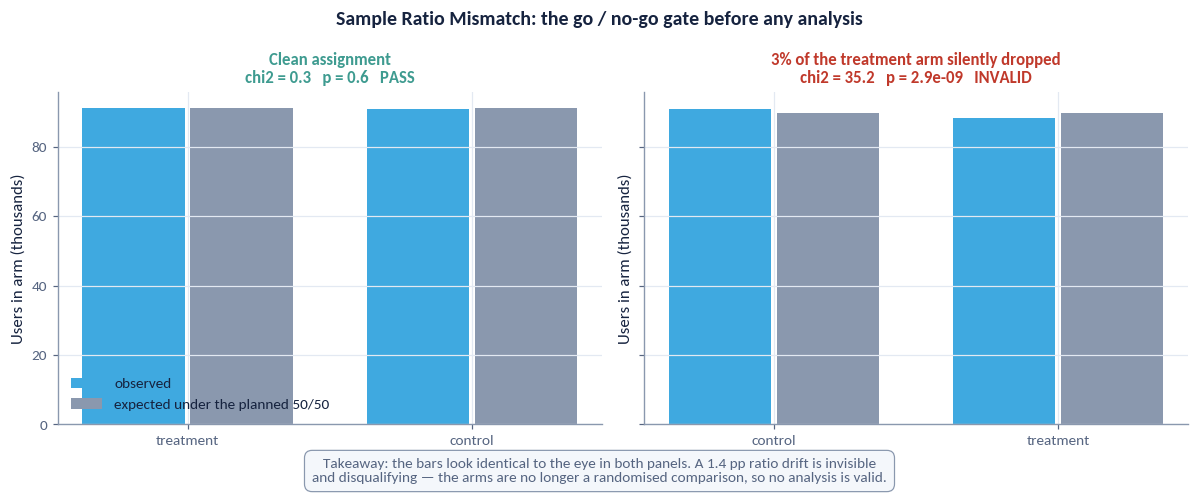

In [8]:
def plot_srm(clean, bad):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
    for ax, res, title in [(axes[0], clean, "Clean assignment"),
                           (axes[1], bad, "3% of the treatment arm silently dropped")]:
        arms = res["arms"]
        x = np.arange(len(arms))
        ax.bar(x - 0.19, np.array(res["observed"]) / 1000, width=0.36,
               color=BLUE, label="observed")
        ax.bar(x + 0.19, np.array(res["expected"]) / 1000, width=0.36,
               color=MUTED, label="expected under the planned 50/50")
        ax.set_xticks(x)
        ax.set_xticklabels(arms)
        ax.set_ylabel("Users in arm (thousands)")
        verdict = "PASS" if not res["srm_detected"] else "INVALID"
        colour = TEAL if not res["srm_detected"] else "#C0392B"
        ax.set_title(f"{title}\nchi2 = {res['chi2']:,.1f}   p = {res['p_value']:.2g}   {verdict}",
                     color=colour, fontsize=11)
    axes[0].legend(loc="lower left")
    fig.suptitle("Sample Ratio Mismatch: the go / no-go gate before any analysis",
                 fontsize=13, fontweight="bold", color=NAVY)
    fig.text(0.5, -0.04,
             "Takeaway: the bars look identical to the eye in both panels. A 1.4 pp ratio drift "
             "is invisible\nand disqualifying — the arms are no longer a randomised comparison, "
             "so no analysis is valid.",
             ha="center", fontsize=10, color=SLATE,
             bbox=dict(boxstyle="round,pad=0.5", fc=PANEL, ec=MUTED, lw=0.8))
    plt.tight_layout()
    plt.show()


plot_srm(srm_clean, srm_broken)

> ### Instructor note — Step 3
>
> **Teaching point.** Clean data gives χ² ≈ 0.27, p ≈ 0.61. The 3% injection gives
> χ² ≈ 35, p ≈ 2.9 × 10⁻⁹ — nine orders of magnitude, from a defect nobody would spot in a
> bar chart. That gap is the whole argument for automating the check.
>
> **Common wrong answer.** "It's only 1.4% off, let's just weight the arms." Shut this
> down hard: the missing users are not missing at random — whatever dropped them may well
> correlate with the outcome. Weighting a non-random loss re-imports exactly the selection
> bias Lab 1 spent an hour removing.
>
> **When a participant is stuck.** If the clean check *fails*, they almost certainly used
> α = 0.05 with the wrong expected counts, or passed proportions where counts were needed.
> Have them print `observed` and `expected` — they should sum to the same total.

---
## Step 4 *(10 min)* — Covariate balance, and the trap in this step

Randomisation balances covariates **in expectation** — not in any single draw. So you
check. The standard tool is the **standardised mean difference (الفرق المعياري في المتوسطات)**:

$$\text{SMD} = \frac{\bar{x}_{\text{treatment}} - \bar{x}_{\text{control}}}{\sqrt{(s^2_t + s^2_c)/2}}$$

Scale-free, so the same |SMD| < 0.1 threshold works for age in years, literacy in [0,1],
and a region indicator alike. **Categoricals must be one-hot expanded** — "region is
balanced" is not one number, each region is its own check.

> ### ⚠️ The trap in this step
> When a covariate comes out imbalanced, someone will want to **re-randomise until it
> looks better**. That is p-hacking the design: you are selecting an assignment on a
> property of the sample, which breaks the independence that made the assignment worth
> anything. **Randomise once, check, and adjust in analysis (Module 4).** Never re-roll.


In [9]:
def smd(df, covariate, variant_col="variant", treated_label="treatment"):
    """Standardised mean difference for one numeric covariate."""
    t = pd.to_numeric(df.loc[df[variant_col] == treated_label, covariate], errors="coerce").dropna()
    c = pd.to_numeric(df.loc[df[variant_col] != treated_label, covariate], errors="coerce").dropna()
    pooled_sd = np.sqrt((t.var(ddof=1) + c.var(ddof=1)) / 2)
    return 0.0 if pooled_sd == 0 else float((t.mean() - c.mean()) / pooled_sd)


def my_balance_table(df, covariates, variant_col="variant", threshold=0.10):
    """One row per covariate; categoricals expanded to one indicator per level."""
    rows = []
    for col in covariates:
        s = df[col]
        if pd.api.types.is_numeric_dtype(s):
            rows.append({"covariate": col, "smd": smd(df, col, variant_col)})
        else:
            for level in sorted(s.dropna().unique()):
                tmp = df.assign(**{f"_{col}_{level}": (s == level).astype(float)})
                rows.append({"covariate": f"{col}={level}",
                             "smd": smd(tmp, f"_{col}_{level}", variant_col)})
    out = pd.DataFrame(rows)
    out["abs_smd"] = out["smd"].abs()
    out["balanced"] = out["abs_smd"] < threshold
    return out.sort_values("abs_smd", ascending=False).reset_index(drop=True)


COVARIATES = ["age", "digital_literacy_score", "prior_completion_rate", "prior_sessions",
              "device_age_years", "distance_km", "region", "device"]

bal = my_balance_table(eligible, COVARIATES)
lib_bal = balance_table(eligible, "variant", COVARIATES)

print(bal.head(10).round(4).to_string(index=False))
print()
print(f"covariates checked      : {len(bal)}")
print(f"max |SMD|               : {bal['abs_smd'].max():.4f}")
print(f"all below 0.10          : {bool(bal['balanced'].all())}")
print(f"causal_utils max |SMD|  : {lib_bal['abs_smd'].max():.4f}   (must match)")

              covariate     smd  abs_smd  balanced
          region=Makkah -0.0091   0.0091      True
            region=Hail  0.0073   0.0073      True
            region=Asir  0.0066   0.0066      True
         device=android -0.0061   0.0061      True
region=Eastern Province  0.0058   0.0058      True
          region=Najran -0.0055   0.0055      True
          region=Riyadh  0.0051   0.0051      True
       device_age_years -0.0050   0.0050      True
           region=Tabuk -0.0042   0.0042      True
             device=ios  0.0035   0.0035      True

covariates checked      : 22
max |SMD|               : 0.0091
all below 0.10          : True
causal_utils max |SMD|  : 0.0091   (must match)


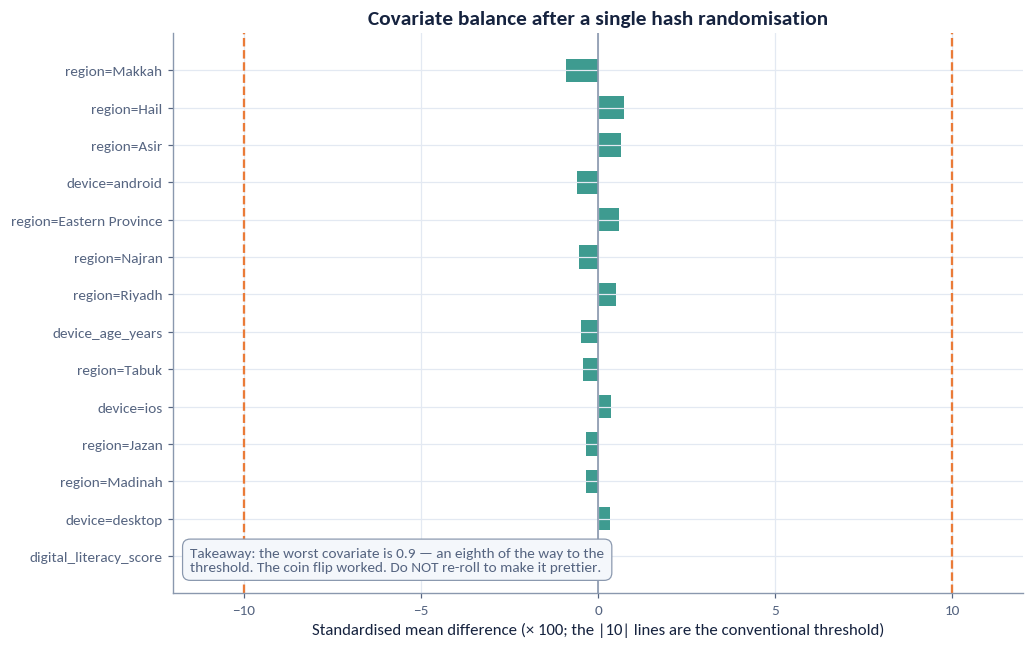

In [10]:
def plot_balance(bal, threshold=0.10):
    top = bal.head(14).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9.5, 6))
    colours = [TEAL if b else ORANGE for b in top["balanced"]]
    ax.barh(top["covariate"], 100 * top["smd"], color=colours, height=0.62)
    for x in (-100 * threshold, 100 * threshold):
        ax.axvline(x, color=ORANGE, ls="--", lw=1.5)
    ax.axvline(0, color=MUTED, lw=1.1)
    ax.set_xlabel("Standardised mean difference (× 100; the |10| lines are the conventional threshold)")
    ax.set_title("Covariate balance after a single hash randomisation")
    ax.set_xlim(-12, 12)
    ax.annotate(
        f"Takeaway: the worst covariate is {100 * bal['abs_smd'].max():.1f} — "
        f"an eighth of the way to the\nthreshold. The coin flip worked. "
        "Do NOT re-roll to make it prettier.",
        xy=(0.02, 0.04), xycoords="axes fraction", fontsize=10, color=SLATE,
        bbox=dict(boxstyle="round,pad=0.5", fc=PANEL, ec=MUTED, lw=0.8))
    plt.tight_layout()
    plt.show()


plot_balance(bal)

> ### Instructor note — Step 4

> **Teaching point.** 22 covariate checks (region and device expanded per level), worst
> |SMD| = **0.009** — a tenth of the conventional 0.10 threshold. Point out that this is
> what a *successful* balance check looks like: boring. The check is not there to be
> interesting, it is there so that when it is *not* boring you find out before you publish.
>
> **The trap, and it will happen.** Someone will propose re-rolling the salt until the worst
> covariate looks better. Stop the room. Re-randomising on a property of the realised sample
> means the assignment is no longer independent of the sample, which is the exact
> independence that made the coin flip worth anything. The correct response to a chance
> imbalance is: note it, and adjust for that covariate in the analysis (Lab 4) — which also
> tightens the interval, so you are paid for doing the honest thing.
>
> **Common wrong answer.** Passing `region` straight into an SMD without one-hot expansion.
> Pandas will happily coerce or drop it and produce one meaningless number. "Region is
> balanced" is thirteen checks, not one.
>
> **When a participant is stuck.** If their table has fewer rows than the library's (22),
> they did not expand the categoricals. Have them diff the `covariate` columns.


### The re-randomisation trap, demonstrated

Suppose you decide to re-roll the salt until *every* covariate has |SMD| < 0.005. It will
eventually happen. The cell below shows what you have actually done: you have chosen the
assignment based on the realised sample, which means the assignment is no longer
independent of the sample. The honest alternative is one salt, one roll, and covariate
adjustment in the analysis — which *also* buys you a tighter confidence interval, for free.


In [11]:
sub = eligible.sample(20_000, random_state=RANDOM_SEED).copy()
rolls = []
for k in range(12):
    sub["v_try"] = hash_assign(sub["user_id"].to_numpy(), f"reroll-attempt-{k}")
    worst = balance_table(sub, "v_try", ["age", "digital_literacy_score",
                                         "prior_completion_rate"])["abs_smd"].max()
    rolls.append({"attempt": k, "worst_abs_smd": round(worst, 4)})

rolls = pd.DataFrame(rolls)
print(rolls.to_string(index=False))
print()
best = rolls.loc[rolls["worst_abs_smd"].idxmin()]
print(f"'Best' roll: attempt {int(best['attempt'])} with worst |SMD| = {best['worst_abs_smd']}")
print()
print("Every one of these twelve rolls is a valid randomisation. Picking the prettiest one")
print("is a choice made using the data, and it is no longer a coin flip. The 12 rolls are")
print("also the honest picture of chance imbalance: this is what 'balanced in expectation'")
print("looks like in practice, and why you check rather than assume.")

 attempt  worst_abs_smd
       0         0.0136
       1         0.0117
       2         0.0139
       3         0.0084
       4         0.0099
       5         0.0085
       6         0.0207
       7         0.0043
       8         0.0170
       9         0.0272
      10         0.0215
      11         0.0133

'Best' roll: attempt 7 with worst |SMD| = 0.0043

Every one of these twelve rolls is a valid randomisation. Picking the prettiest one
is a choice made using the data, and it is no longer a coin flip. The 12 rolls are
also the honest picture of chance imbalance: this is what 'balanced in expectation'
looks like in practice, and why you check rather than assume.


### ✅ Checkpoint B — what you should be seeing by now

≈37 minutes in. SRM passing on clean data and failing hard on the injected bug; a balance
table with a worst |SMD| around 0.009 and every row green.


In [12]:
def checkpoint_b():
    if srm_clean is None or bal is None:
        print("✗ Steps 3-4 incomplete.")
        return
    print(f"✓ SRM, clean data        : chi2 = {srm_clean['chi2']:.2f}, "
          f"p = {srm_clean['p_value']:.3f}  -> {srm_clean['verdict']}")
    print(f"✓ SRM, 3% arm loss       : chi2 = {srm_broken['chi2']:.2f}, "
          f"p = {srm_broken['p_value']:.2g}  -> {srm_broken['verdict']}")
    print(f"✓ balance covariates     : {len(bal)} checked, max |SMD| = {bal['abs_smd'].max():.4f}")
    print(f"✓ all balanced (<0.10)   : {bool(bal['balanced'].all())}")
    print()
    print("The design is now defensible. Next: what could still break it, and freezing the plan.")

checkpoint_b()

✓ SRM, clean data        : chi2 = 0.27, p = 0.605  -> ratios OK
✓ SRM, 3% arm loss       : chi2 = 35.23, p = 2.9e-09  -> INVALID — investigate plumbing
✓ balance covariates     : 22 checked, max |SMD| = 0.0091
✓ all balanced (<0.10)   : True

The design is now defensible. Next: what could still break it, and freezing the plan.


---
## Step 5 *(8 min)* — Interference audit

Before you launch, ask one question: **can one user's treatment change another user's
outcome?** If yes, the user-level A/B test overstates its precision and possibly its
effect, and no amount of sample fixes it.

SUTVA fails in two ways worth naming:

- **Interference / spillover** — shared household devices, call-centre agents who learn
  the new flow and coach control users, capacity effects that free agents for everyone.
- **Multiple versions of the treatment** — "the uploader" is really three builds across
  OS versions, a hidden violation of the single-version assumption.

Containment designs, in order of increasing cost: cluster randomisation (household,
branch, region) → switchback / time-split → two-sided or ego-cluster designs.

Fill the audit below with **at least two** risks specific to this experiment.


In [13]:
INTERFERENCE_AUDIT = [
    {
        "risk": "Shared household or majlis device",
        "mechanism": ("Several citizens use one tablet. Hash assignment is by national-ID, "
                      "so a treated user's household members can watch the guided flow and "
                      "learn it, lifting the control arm's completion."),
        "severity": "medium — dilutes the measured effect toward zero (conservative bias)",
        "design_change": ("Randomise by household where a household key exists; otherwise "
                          "keep user-level randomisation, pre-register the direction of the "
                          "bias, and treat the estimate as a lower bound."),
    },
    {
        "risk": "Call-centre agents coaching control users",
        "mechanism": ("Agents handling support calls learn the guided steps from treated "
                      "users and walk control users through the same sequence by phone. "
                      "Treatment leaks through the support channel."),
        "severity": "high — contaminates the control arm through a channel we do not log",
        "design_change": ("Cluster-randomise by service centre / agent pool, or run the "
                          "experiment only on the fully self-service path and add a "
                          "guardrail on support-contact rate to detect the leak."),
    },
    {
        "risk": "Multiple versions of the 'same' treatment",
        "mechanism": ("The guided uploader ships as three builds (iOS, Android, web) with "
                      "different step counts, so 'the treatment' is not one thing."),
        "severity": "medium — violates the single-version half of SUTVA",
        "design_change": ("Pre-register device as a stratification variable and report the "
                          "per-platform estimate as a pre-planned heterogeneity analysis, "
                          "not a post-hoc segment sweep."),
    },
]

for i, item in enumerate(INTERFERENCE_AUDIT, 1):
    print(f"{i}. {item['risk']}")
    print(f"   mechanism     : {item['mechanism']}")
    print(f"   severity      : {item['severity']}")
    print(f"   design change : {item['design_change']}\n")

assert len(INTERFERENCE_AUDIT) >= 2, "the audit needs at least two risks"
print(f"Audit complete: {len(INTERFERENCE_AUDIT)} SUTVA risks documented with mitigations.")

1. Shared household or majlis device
   mechanism     : Several citizens use one tablet. Hash assignment is by national-ID, so a treated user's household members can watch the guided flow and learn it, lifting the control arm's completion.
   severity      : medium — dilutes the measured effect toward zero (conservative bias)
   design change : Randomise by household where a household key exists; otherwise keep user-level randomisation, pre-register the direction of the bias, and treat the estimate as a lower bound.

2. Call-centre agents coaching control users
   mechanism     : Agents handling support calls learn the guided steps from treated users and walk control users through the same sequence by phone. Treatment leaks through the support channel.
   severity      : high — contaminates the control arm through a channel we do not log
   design change : Cluster-randomise by service centre / agent pool, or run the experiment only on the fully self-service path and add a guardrail on 

> ### Instructor note — Step 5
>
> **Teaching point.** Note that the household-device risk biases the estimate *downward*.
> Participants assume every violation inflates results; naming a conservative bias is a
> more sophisticated move and makes "this is a lower bound" a defensible sentence in the memo.
>
> **Common wrong answer.** "Randomise by region to be safe." Ask how many regions there
> are (13) and what a two-sample test on 13 units can detect. Over-coarsening throws away
> power for a spillover risk that does not exist here — the rule is *coarsest that
> interference demands, and no coarser*.
>
> **When a participant is stuck.** Give them the marketplace case: a fixed pool of
> priority appointment slots. Treated users grab slots *from* control users, so the
> user-level 15% is partly cannibalisation, not net improvement. Once they see one
> finite-resource example the others come quickly.

---
## Step 6 *(7 min)* — Freeze the analysis plan

Pre-registration in miniature. Everything you must commit to **before** any outcome is
visible goes into an `AnalysisPlan`, which is then stamped and hashed. Put the hash in
the decision memo and a reader can verify nothing moved between design and analysis.

Metrics chosen after seeing data are not metrics — they are conclusions with a p-value
stapled on. This object is what Lab 4 opens.


In [14]:
from causal_utils import AnalysisPlan, freeze_plan

plan = AnalysisPlan(
    experiment_name=DESIGN_DOC["experiment_name"],
    decision=DESIGN_DOC["decision"],
    randomisation_unit=DESIGN_DOC["randomisation_unit"],
    oec=DESIGN_DOC["oec"],
    guardrails=DESIGN_DOC["guardrails"],
    trigger_definition=DESIGN_DOC["trigger_definition"],
    unit_of_analysis=DESIGN_DOC["unit_of_analysis"],
    mde=DESIGN_DOC["mde_absolute"],
    alpha=DESIGN_DOC["alpha"],
    power=DESIGN_DOC["power"],
    correction_family=("no correction for the single OEC; Bonferroni across the "
                       "guardrail family; Benjamini-Hochberg for any segment sweep"),
    stopping_rule=DESIGN_DOC["stopping_rule"],
    practical_threshold=DESIGN_DOC["practical_threshold"],
)
plan = freeze_plan(plan)

out_path = ROOT / "notebooks" / "lab2_frozen_plan.json"
out_path.write_text(plan.to_json())
print(f"\nwritten to {out_path.name} — Lab 4 opens this file before it opens the results.")
print()
print(plan.to_json())

Analysis plan FROZEN at 2026-09-07T17:21:00+00:00
  hash: b47e305fe7c01612

written to lab2_frozen_plan.json — Lab 4 opens this file before it opens the results.

{
  "alpha": 0.05,
  "correction_family": "no correction for the single OEC; Bonferroni across the guardrail family; Benjamini-Hochberg for any segment sweep",
  "decision": "Ship the guided document uploader to all Injaz users, or keep the current plain uploader?",
  "experiment_name": "injaz-guided-uploader-2026q2",
  "frozen_at": "2026-09-07T17:21:00+00:00",
  "guardrails": [
    "time-to-complete (session_duration_sec) - must not rise materially",
    "support-contact rate - must not rise",
    "upload-error rate (error_flag) - must not rise"
  ],
  "mde": 0.02,
  "oec": "service-completion rate among triggered users",
  "plan_hash": "b47e305fe7c01612",
  "planned_n_per_arm": null,
  "planned_run_days": null,
  "power": 0.8,
  "practical_threshold": 0.01,
  "randomisation_unit": "user (national-ID hash)",
  "stopping_rule

> ### Instructor note — Step 6
>
> **Teaching point.** The hash is the point, not the JSON. Ask: "If the OEC changes in
> Lab 4, what happens to this hash?" It changes, visibly, and the reader of the memo can
> tell. That is the entire mechanism of pre-registration compressed into one field.
>
> **Common wrong answer.** Leaving `practical_threshold` at the default without discussing
> it. A 1.0 pp threshold is a *business* decision about build cost, not a statistical one —
> and in the capstone it is exactly the number that turns a significant result into a "hold".
>
> **When a participant is stuck.** `freeze_plan` mutates and returns the plan; if they
> forget the reassignment (`plan = freeze_plan(plan)`) the object is still fine because it
> is mutated in place — mention it so nobody loses two minutes on it.

---
## Step 7 — Grade yourself against the planted ground truth

`GROUND_TRUTH.json` records what the course generator actually produced. Compare your
eligible count, your realised allocation, and your SRM verdicts against it.


In [15]:
M2 = GROUND_TRUTH["module2_user_pool"]
M4 = GROUND_TRUTH["module4_uploader_experiment"]

checks = [
    ("pool rows", len(pool), M2["rows"]),
    ("eligible rows", len(eligible), M2["eligible"]),
    ("treatment share (this randomisation)",
     round(float((eligible["variant"] == "treatment").mean()), 4)
     if eligible["variant"].notna().all() else float("nan"), 0.5),
    ("treatment share (course experiment file)",
     M4["allocation_treatment"], 0.5),
    ("treatment share (SRM-broken file)",
     M4["srm_broken_allocation"], 0.5),
]

print(f"{'quantity':<42}{'value':>14}{'target':>12}   verdict")
print("-" * 82)
for name, got, want in checks:
    if isinstance(got, int):
        ok = got == want
        print(f"{name:<42}{got:>14,}{want:>12,}   {'MATCH' if ok else 'CHECK'}")
    else:
        ok = abs(got - want) < 0.005 if got == got else False
        print(f"{name:<42}{got:>14.4f}{want:>12.4f}   "
              f"{'within 0.5 pp' if ok else 'SRM TERRITORY'}")

print()
print("Read the last two rows together. 0.5007 is a healthy experiment; 0.4928 is the")
print("SRM-broken file, and the difference between them is 0.8 percentage points.")
print("That is the entire margin between a result you can ship and one you must throw away.")

quantity                                           value      target   verdict
----------------------------------------------------------------------------------
pool rows                                        200,000     200,000   MATCH
eligible rows                                    182,113     182,113   MATCH
treatment share (this randomisation)              0.5006      0.5000   within 0.5 pp
treatment share (course experiment file)          0.5007      0.5000   within 0.5 pp
treatment share (SRM-broken file)                 0.4928      0.5000   SRM TERRITORY

Read the last two rows together. 0.5007 is a healthy experiment; 0.4928 is the
SRM-broken file, and the difference between them is 0.8 percentage points.
That is the entire margin between a result you can ship and one you must throw away.


### Benchmark table for Module 2 (fill this in from your own run)

| Check | Result | Verdict |
|---|---|---|
| Randomisation determinism (3 re-runs) | | |
| SRM, intended 50/50 | | |
| SRM, injected 3% arm loss | | |
| Balance, max abs SMD | | |
| Design-doc completeness (6 fields) | | |
| Interference risks identified | | |


---
## What you now own

In [16]:
print("""
TOOLKIT CONTRIBUTION — Lab 2
============================================================
Reusable artefacts you built and can lift into any project:

  assign_variant(unit_id, salt, split, arms)
      Deterministic, stateless, hash-based bucketing. Identical in the
      serving layer and the analysis pipeline, months apart. One salt per
      experiment keeps concurrent tests independent.

  srm_check_manual(variant, expected_split, alpha=0.001)
      The go / no-go gate. Run it BEFORE you compute any effect. A failing
      SRM is not a number to adjust, it is an experiment to rerun.

  smd(df, covariate) / my_balance_table(df, covariates)
      Scale-free balance checking with categoricals expanded per level.
      Run once, report, and adjust in analysis - never re-roll.

  DESIGN_DOC  +  INTERFERENCE_AUDIT
      The one-page design document and the SUTVA audit. These are the
      artefacts a reviewer reads first and a post-mortem reads last.

  lab2_frozen_plan.json  (AnalysisPlan, hashed)
      Pre-registration in miniature. Lab 4 opens this file BEFORE it opens
      the results, and the memo quotes its hash.

Carried forward:
  - Lab 3 turns DESIGN_DOC["mde_absolute"] into a sample size and a calendar.
  - Lab 4 opens the frozen plan, checks SRM again on the real results, and
    analyses the TRIGGERED users this design defined.
============================================================
""")


TOOLKIT CONTRIBUTION — Lab 2
Reusable artefacts you built and can lift into any project:

  assign_variant(unit_id, salt, split, arms)
      Deterministic, stateless, hash-based bucketing. Identical in the
      serving layer and the analysis pipeline, months apart. One salt per
      experiment keeps concurrent tests independent.

  srm_check_manual(variant, expected_split, alpha=0.001)
      The go / no-go gate. Run it BEFORE you compute any effect. A failing
      SRM is not a number to adjust, it is an experiment to rerun.

  smd(df, covariate) / my_balance_table(df, covariates)
      Scale-free balance checking with categoricals expanded per level.
      Run once, report, and adjust in analysis - never re-roll.

  DESIGN_DOC  +  INTERFERENCE_AUDIT
      The one-page design document and the SUTVA audit. These are the
      artefacts a reviewer reads first and a post-mortem reads last.

  lab2_frozen_plan.json  (AnalysisPlan, hashed)
      Pre-registration in miniature. Lab 4 opens

---
## Mini-exercises

### 1 · Quiz

1. When should you randomise by user rather than by session?
2. What is an OEC, and how many should an experiment have?
3. What does an SRM indicate, and what should you do about it?
4. Name a SUTVA-violating scenario and the containment design it demands.
5. Why hash instead of drawing a random number per request?

### 2 · Debugging exercise — the non-deterministic assignment

The cell below re-seeds the generator inside the loop, so the same user can land in
different arms across calls. Run it, then answer: what does the SRM check say, and why is
SRM *not* the diagnostic that catches this bug?

### 3 · Design critique

Three one-line designs. Name the flaw and the fix for each:

| # | Design | Flaw | Fix |
|---|---|---|---|
| a | "Session-level randomisation for a returning-user onboarding feature" | | |
| b | "Twelve primary metrics so we learn more" | | |
| c | "Region-level randomisation across our 13 regions, analysed with a standard z-test" | | |

### 4 · Discussion

- Your PM wants five "primary" metrics. What is the statistical cost, and what is your
  counter-proposal?
- A marketplace-style feature cannot be user-randomised safely. Walk through choosing
  between a cluster design and a switchback design.


In [17]:
# --- Mini-exercise 2: the non-deterministic assignment --------------------
def assign_variant_BROKEN(unit_id, experiment_salt):
    """DELIBERATELY WRONG: a fresh random draw per call instead of a hash."""
    return np.random.default_rng().choice(["control", "treatment"])


sample_ids = eligible["user_id"].head(20_000).to_numpy()
run_a = np.array([assign_variant_BROKEN(u, SALT) for u in sample_ids])
run_b = np.array([assign_variant_BROKEN(u, SALT) for u in sample_ids])

print(f"same arm across two runs : {(run_a == run_b).mean():.3f}   (a correct hash gives 1.000)")
print()
print("And the SRM check on run A:")
print(srm_check(pd.Series(run_a), {"control": 0.5, "treatment": 0.5}))
print()
print("SRM PASSES. That is the lesson: SRM detects units LOST from an arm, not units")
print("shuffled BETWEEN arms. The diagnostic for non-determinism is re-running the")
print("assignment and comparing - which is why the determinism check in Step 2 exists.")

same arm across two runs : 0.499   (a correct hash gives 1.000)

And the SRM check on run A:
Sample Ratio Mismatch check: PASS
  chi2 = 2.25   p = 0.134
  control      observed   10,106   expected     10,000   (+1.06%)
  treatment    observed    9,894   expected     10,000   (-1.06%)

SRM PASSES. That is the lesson: SRM detects units LOST from an arm, not units
shuffled BETWEEN arms. The diagnostic for non-determinism is re-running the
assignment and comparing - which is why the determinism check in Step 2 exists.


> ### Instructor note — mini-exercise answers
>
> **Quiz.** (1) When users return and must see a consistent experience, or when sessions
> within a user are not independent. (2) The single metric that decides the experiment;
> exactly one. (3) A likely plumbing bug — do not analyse until it is explained and fixed.
> (4) Shared household devices / finite appointment slots → cluster or switchback
> randomisation. (5) Deterministic, stateless and reproducible, and independent across
> concurrent experiments via the salt.
>
> **Debugging exercise.** The broken assignment agrees with itself on ~50% of users, yet
> SRM passes cleanly (χ² ≈ 0–2). This surprises everyone and it is the point: SRM catches
> *missing* units, not *reshuffled* ones. Non-determinism is caught by re-running the
> assignment, which is why the Step 2 determinism check is not optional ceremony.
>
> **Design critique.** (a) A returning-user feature randomised by session breaks both
> consistency and independence → randomise by user. (b) Twelve primary metrics give a
> ~46% chance of at least one false positive → one OEC, guardrails under Bonferroni, the
> rest labelled diagnostic. (c) 13 regions is 13 independent units; a standard z-test on
> user rows treats ~180,000 correlated rows as independent → cluster-robust variance,
> randomisation inference, or a switchback across many weeks.
>
> **Discussion.** Five primary metrics ≈ 23% family-wise error; counter-proposal is one
> OEC plus a labelled guardrail family. Cluster vs switchback: cluster when the spillover
> is *spatial* (regions, branches, households) and you have enough clusters; switchback
> when the spillover is through a *shared finite resource* and you have few units but many
> time periods.